# HR Analytics — Exploratory Data Analysis
## Analyst: Anusha Chowdary
## Dataset: IBM HR Analytics (1,470 employees, 35 columns)
## Tool: Python (Pandas, Matplotlib, Seaborn)

### Project Overview
This project analyzes IBM HR Analytics data to uncover 
insights about employee attrition, salary distribution 
and departmental performance.

### Key Questions Answered
1. Which department has the highest attrition?
2. What is the age distribution of employees?
3. Which job roles earn the most and least?
4. What is the overall attrition rate?

### Key Findings
- R&D department has the highest attrition
- Average employee age is 37 years
- Managers earn the most — Sales Reps earn the least
- 16.12% attrition rate — above industry average of 15%
- 20x salary gap — Min $1,009 to Max $19,999

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hr_analytics.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Check all column names
print("Column Names:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset Info:")
df.info()

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null

In [3]:
# Basic statistics of the dataset
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
# Monthly Income statistics only
print("Monthly Income Statistics:")
print(df['MonthlyIncome'].describe())


Monthly Income Statistics:
count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


In [5]:
# Check attrition rate
print("Attrition Count:")
print(df['Attrition'].value_counts())

print("\nAttrition Rate:")
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(round(attrition_rate, 2))

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [6]:
print("Shape of dataset:", df.shape)
print("Total Employees:", len(df))
print("Total Columns:", len(df.columns))

Shape of dataset: (1470, 35)
Total Employees: 1470
Total Columns: 35


In [7]:
print("Shape of dataset:", df.shape)
print("Total Employees:", len(df))
print("Total Columns:", len(df.columns))

Shape of dataset: (1470, 35)
Total Employees: 1470
Total Columns: 35


In [8]:
print("Monthly Income Statistics:")
print(df['MonthlyIncome'].describe().round(2))


Monthly Income Statistics:
count     1470.00
mean      6502.93
std       4707.96
min       1009.00
25%       2911.00
50%       4919.00
75%       8379.00
max      19999.00
Name: MonthlyIncome, dtype: float64


In [9]:
print("Attrition Rate:")
attrition = df['Attrition'].value_counts(normalize=True) * 100
print(round(attrition, 2))


Attrition Rate:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [10]:
# Check columns with only one unique value — useless for analysis
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Column '{col}' has only 1 unique value: {df[col].unique()}")

Column 'EmployeeCount' has only 1 unique value: [1]
Column 'Over18' has only 1 unique value: <StringArray>
['Y']
Length: 1, dtype: str
Column 'StandardHours' has only 1 unique value: [80]


In [11]:
# Drop useless columns
df_clean = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

# Also drop EmployeeNumber — it's just an ID, not useful for analysis
df_clean = df_clean.drop(columns=['EmployeeNumber'])

# Confirm columns removed
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("\nColumns removed: EmployeeCount, Over18, StandardHours, EmployeeNumber")
print("Remaining columns:", df_clean.shape[1])

Original shape: (1470, 35)
Cleaned shape: (1470, 31)

Columns removed: EmployeeCount, Over18, StandardHours, EmployeeNumber
Remaining columns: 31


In [12]:
# Check columns that should be categories not numbers
cat_columns = ['Education', 'EnvironmentSatisfaction', 
               'JobInvolvement', 'JobLevel', 
               'JobSatisfaction', 'PerformanceRating',
               'RelationshipSatisfaction', 'StockOptionLevel',
               'TrainingTimesLastYear', 'WorkLifeBalance']

# Convert to category type
for col in cat_columns:
    df_clean[col] = df_clean[col].astype('category')

print("✅ Converted these columns to category type:")
for col in cat_columns:
    print(f"   {col}: {df_clean[col].dtype}")

✅ Converted these columns to category type:
   Education: category
   EnvironmentSatisfaction: category
   JobInvolvement: category
   JobLevel: category
   JobSatisfaction: category
   PerformanceRating: category
   RelationshipSatisfaction: category
   StockOptionLevel: category
   TrainingTimesLastYear: category
   WorkLifeBalance: category


In [13]:
# Create new calculated columns
# 1. Salary Category
df_clean['SalaryCategory'] = pd.cut(
    df_clean['MonthlyIncome'],
    bins=[0, 3000, 7000, 12000, 20000],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 2. Experience Category
df_clean['ExperienceCategory'] = pd.cut(
    df_clean['TotalWorkingYears'],
    bins=[0, 2, 5, 10, 40],
    labels=['Fresher', 'Junior', 'Mid', 'Senior']
)

# 3. Age Group
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60']
)

# Confirm new columns
print("New columns created:")
print(df_clean[['MonthlyIncome', 'SalaryCategory', 
                'TotalWorkingYears', 'ExperienceCategory',
                'Age', 'AgeGroup']].head(10))

New columns created:
   MonthlyIncome SalaryCategory  TotalWorkingYears ExperienceCategory  Age  \
0           5993         Medium                  8                Mid   41   
1           5130         Medium                 10                Mid   49   
2           2090            Low                  7                Mid   37   
3           2909            Low                  8                Mid   33   
4           3468         Medium                  6                Mid   27   
5           3068         Medium                  8                Mid   32   
6           2670            Low                 12             Senior   59   
7           2693            Low                  1            Fresher   30   
8           9526           High                 10                Mid   38   
9           5237         Medium                 17             Senior   36   

  AgeGroup  
0    36-45  
1    46-60  
2    36-45  
3    26-35  
4    26-35  
5    26-35  
6    46-60  
7    26-35  
8  

In [14]:
# Before vs After cleaning summary
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)
print(f"\nBEFORE CLEANING:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.shape[1]}")
print(f"  Useless columns: 4")
print(f"  Numeric cols used as categories: 10")
print(f"  Calculated columns: 0")

print(f"\nAFTER CLEANING:")
print(f"  Shape: {df_clean.shape}")
print(f"  Columns: {df_clean.shape[1]}")
print(f"  Useless columns removed: 4")
print(f"  Properly typed category cols: 10")
print(f"  New calculated columns added: 3")

print(f"\nNEW COLUMNS CREATED:")
print(f"  SalaryCategory: Low/Medium/High/Very High")
print(f"  ExperienceCategory: Fresher/Junior/Mid/Senior")
print(f"  AgeGroup: 18-25/26-35/36-45/46-60")
print("=" * 50)
print("Data is now ready for analysis! ✅")

DATA CLEANING SUMMARY

BEFORE CLEANING:
  Shape: (1470, 35)
  Columns: 35
  Useless columns: 4
  Numeric cols used as categories: 10
  Calculated columns: 0

AFTER CLEANING:
  Shape: (1470, 34)
  Columns: 34
  Useless columns removed: 4
  Properly typed category cols: 10
  New calculated columns added: 3

NEW COLUMNS CREATED:
  SalaryCategory: Low/Medium/High/Very High
  ExperienceCategory: Fresher/Junior/Mid/Senior
  AgeGroup: 18-25/26-35/36-45/46-60
Data is now ready for analysis! ✅


In [15]:
# Save cleaned dataset
df_clean.to_csv('hr_analytics_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as hr_analytics_cleaned.csv")
print(f"Final shape: {df_clean.shape}")
print(f"Ready for visualization!")

✅ Cleaned dataset saved as hr_analytics_cleaned.csv
Final shape: (1470, 34)
Ready for visualization!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df_clean = pd.read_csv('hr_analytics_cleaned.csv')
print("Data loaded successfully!")
print("Shape:", df_clean.shape)

# Set visual style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

Data loaded successfully!
Shape: (1470, 34)


<Figure size 1200x600 with 0 Axes>

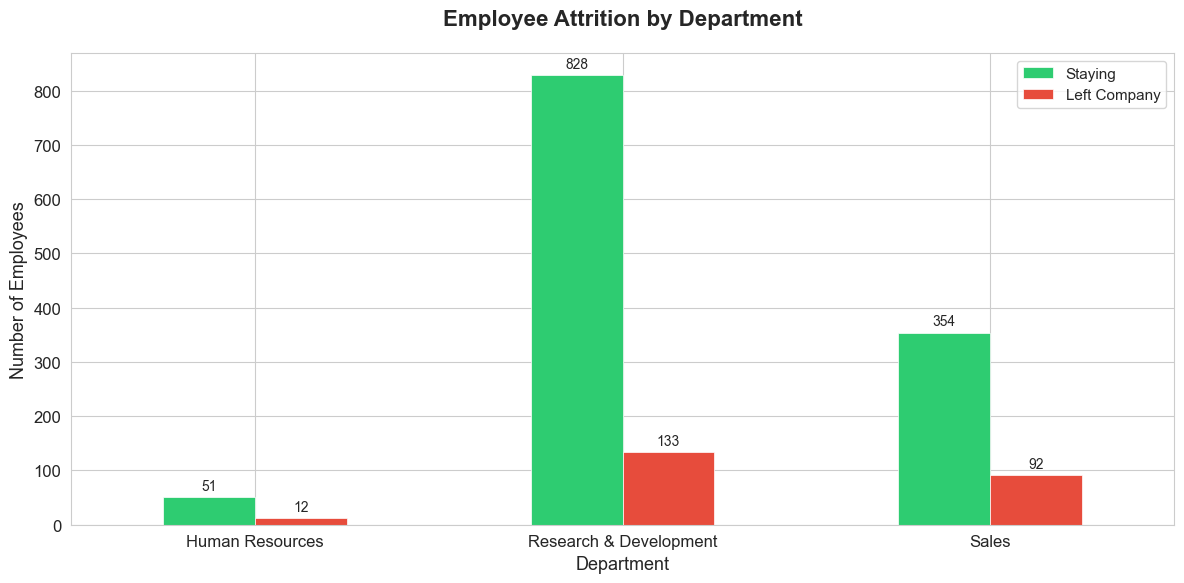

Chart 1 saved!


In [2]:
# Chart 1 — Attrition by Department
plt.figure(figsize=(12, 6))

# Count attrition by department
dept_attrition = df_clean.groupby(['Department', 'Attrition']).size().unstack()

# Plot
dept_attrition.plot(kind='bar', 
                    color=['#2ecc71', '#e74c3c'],
                    figsize=(12, 6),
                    edgecolor='white',
                    linewidth=0.5)

# Labels and title
plt.title('Employee Attrition by Department', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department', fontsize=13)
plt.ylabel('Number of Employees', fontsize=13)
plt.xticks(rotation=0, fontsize=12)
plt.legend(['Staying', 'Left Company'], fontsize=11)

# Add value labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fontsize=10, padding=3)

plt.tight_layout()
plt.savefig('chart1_attrition_by_department.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

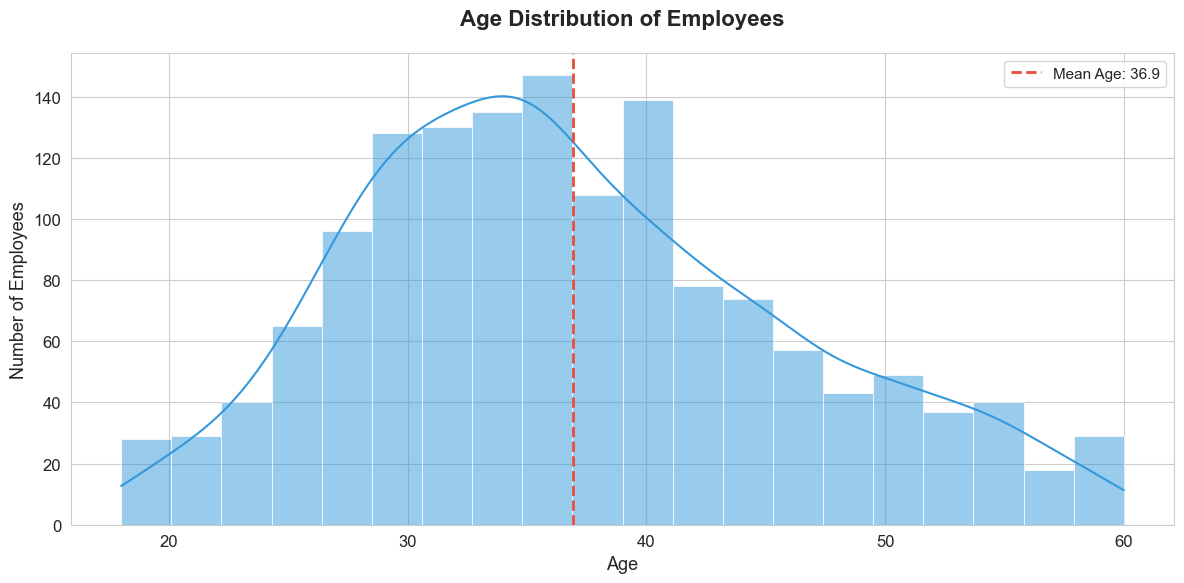

Chart 2 saved!


In [4]:
# Chart 2 — Age Distribution
plt.figure(figsize=(12, 6))

# Plot histogram without kde_kws color issue
sns.histplot(data=df_clean, 
             x='Age', 
             bins=20,
             color='#3498db',
             edgecolor='white',
             linewidth=0.5,
             kde=True)

# Add vertical line for mean age
mean_age = df_clean['Age'].mean()
plt.axvline(mean_age, 
            color='#e74c3c', 
            linestyle='--', 
            linewidth=2,
            label=f'Mean Age: {mean_age:.1f}')

# Labels and title
plt.title('Age Distribution of Employees', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age', fontsize=13)
plt.ylabel('Number of Employees', fontsize=13)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart2_age_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

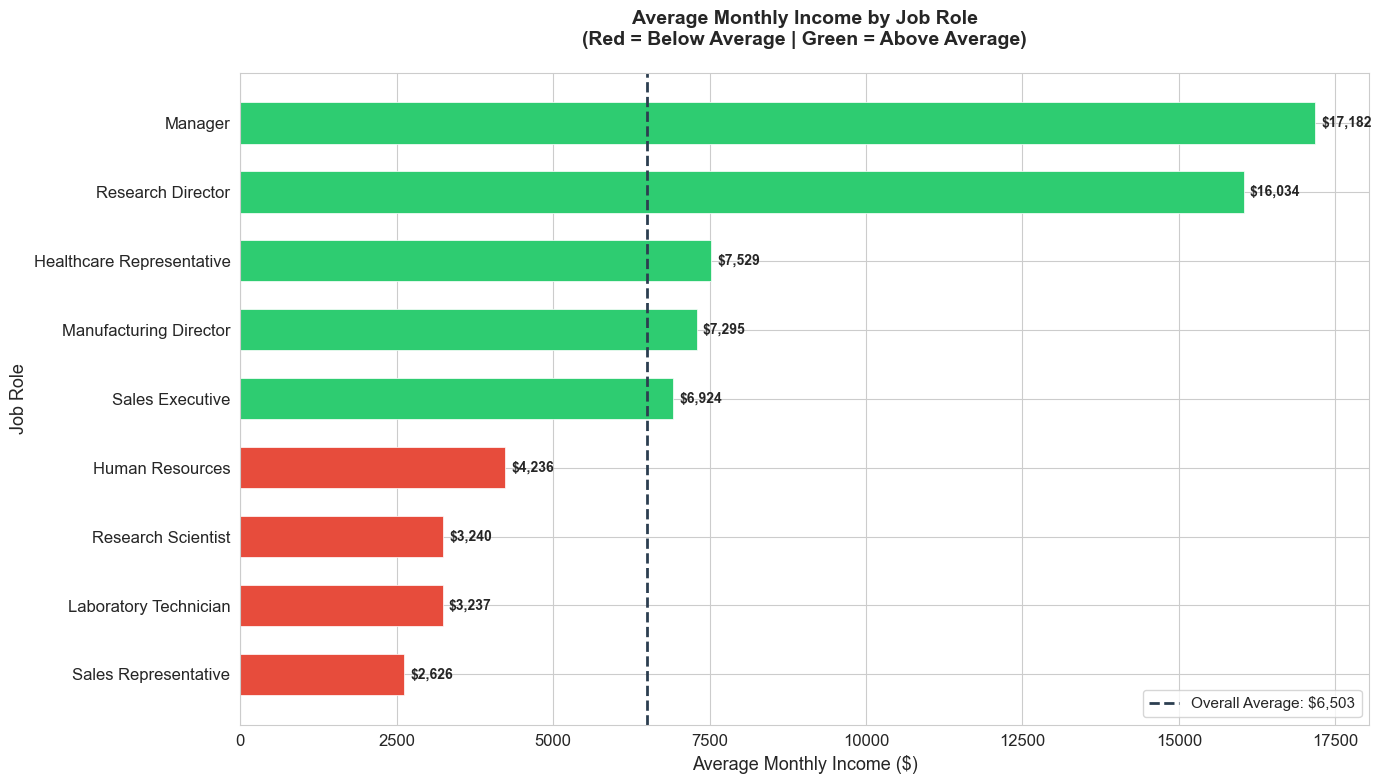

Chart 3 saved!


In [5]:
# Chart 3 — Monthly Income by Job Role
plt.figure(figsize=(14, 8))

# Calculate average salary per job role
job_salary = df_clean.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=True)

# Plot horizontal bar chart
colors = ['#e74c3c' if x < df_clean['MonthlyIncome'].mean() 
          else '#2ecc71' for x in job_salary.values]

plt.barh(job_salary.index, 
         job_salary.values,
         color=colors,
         edgecolor='white',
         linewidth=0.5,
         height=0.6)

# Add vertical line for overall average
overall_avg = df_clean['MonthlyIncome'].mean()
plt.axvline(overall_avg,
            color='#2c3e50',
            linestyle='--',
            linewidth=2,
            label=f'Overall Average: ${overall_avg:,.0f}')

# Add value labels on bars
for i, (value, label) in enumerate(zip(job_salary.values, job_salary.index)):
    plt.text(value + 100, i, f'${value:,.0f}', 
             va='center', fontsize=10, fontweight='bold')

# Labels and title
plt.title('Average Monthly Income by Job Role\n(Red = Below Average | Green = Above Average)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Average Monthly Income ($)', fontsize=13)
plt.ylabel('Job Role', fontsize=13)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart3_salary_by_jobrole.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

## Project Summary & Business Recommendations

### What We Found:

| Finding | Insight | Recommendation |
|---------|---------|---------------|
| Attrition Rate | 16.12% — above 15% avg | Launch retention program immediately |
| Highest Attrition | R&D Department | Invest in R&D employee benefits |
| Average Age | 37 years | Focus retention on 30-40 age group |
| Lowest Paid Role | Sales Representatives | Review Sales Rep compensation urgently |
| Salary Gap | 20x between min and max | Conduct pay equity audit |

### Tools Used
- Python 3.13
- Pandas — data loading, cleaning, feature engineering
- Matplotlib — bar charts and histograms
- Seaborn — statistical visualizations

### Dataset
- Source: Kaggle — IBM HR Analytics Dataset
- Rows: 1,470 employees
- Columns: 35 (cleaned to 31 + 3 new columns created)

### Connect
- GitHub: github.com/Anusha3-d
- LinkedIn: linkedin.com/in/anusha-chowdary-d-843192295